In [1]:
!pip install -q mlflow
!pip install -q --no-cache-dir --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git@main

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
print("--- autoencodeurs.py sur GitHub (main) ---")
!curl -s https://raw.githubusercontent.com/RayenSansa03/aeroguard/main/src/aeroguard/autoencodeurs.py | grep -n "^def "
print("\n--- autoencodeurs.py installé dans Colab ---")
!grep -n "^def " $(python -c "import aeroguard, os; print(os.path.dirname(aeroguard.__file__))")/autoencodeurs.py

--- autoencodeurs.py sur GitHub (main) ---
8:def statistiques_features(X):
19:def standardiser(X, moyennes, ecarts):
24:def creer_autoencodeur_dense(
53:def erreur_reconstruction(modele, X, par_feature=False):

--- autoencodeurs.py installé dans Colab ---
8:def statistiques_features(X):
19:def standardiser(X, moyennes, ecarts):
24:def creer_autoencodeur_dense(
53:def erreur_reconstruction(modele, X, par_feature=False):


In [3]:
from google.colab import drive
drive.mount("/content/drive")

import math
import os
import shutil
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.impute import SimpleImputer

from aeroguard.autoencodeurs import standardiser, statistiques_features
from aeroguard.donnees_ml import preparer_xy

DOSSIER = "/content/drive/MyDrive/aeroguard"
DOSSIER_MLFLOW_LOCAL = "/content/mlflow"
DOSSIER_MLFLOW_DRIVE = f"{DOSSIER}/mlflow"
if os.path.exists(DOSSIER_MLFLOW_DRIVE) and not os.path.exists(DOSSIER_MLFLOW_LOCAL):
    shutil.copytree(DOSSIER_MLFLOW_DRIVE, DOSSIER_MLFLOW_LOCAL)
if os.path.exists(f"{DOSSIER}/mlruns") and not os.path.exists("/content/mlruns"):
    shutil.copytree(f"{DOSSIER}/mlruns", "/content/mlruns")
os.makedirs(DOSSIER_MLFLOW_LOCAL, exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{DOSSIER_MLFLOW_LOCAL}/mlflow.db")

vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")
infos_val = vols.loc[X_val.index, ["moteur", "cycle", "RUL"]].reset_index(drop=True)

imputeur = SimpleImputer(strategy="median").fit(X_train)
Xi_train = imputeur.transform(X_train)
Xi_val = imputeur.transform(X_val)

sains_train = (y_train == 0).to_numpy()   # y = 1 usé, 0 sain
sains_val = (y_val == 0).to_numpy()

# Référence « normale » = statistiques des vols SAINS du train uniquement
moyennes, ecarts = statistiques_features(Xi_train[sains_train])
Xn_train = standardiser(Xi_train, moyennes, ecarts)
Xn_val = standardiser(Xi_val, moyennes, ecarts)

print("TensorFlow", tf.__version__)
print(f"Train : {sains_train.sum()} vols sains (pour apprendre) sur {len(sains_train)}")
print(f"Validation : {sains_val.sum()} sains, {(~sains_val).sum()} usés (pour évaluer)")

Mounted at /content/drive
TensorFlow 2.21.0
Train : 1096 vols sains (pour apprendre) sur 3716
Validation : 244 sains, 575 usés (pour évaluer)


In [4]:
from aeroguard.autoencodeurs import creer_autoencodeur_dense
from aeroguard.reseaux import nombre_parametres_entrainables

autoencodeur = creer_autoencodeur_dense(Xn_train.shape[1])
autoencodeur.summary()
print("Paramètres entraînables :", nombre_parametres_entrainables(autoencodeur))

Model: "aeroguard_autoencodeur"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encodeur_1 (Dense)              │ (None, 64)             │         8,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encodeur_2 (Dense)              │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ goulot (Dense)                  │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decodeur_1 (Dense)              │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decodeur_2 (Dense)              │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 126)            │         8,190 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,726 (73.15 KB)

 Trainable params: 18,726 (73.15 KB)

 Non-trainable params: 0 (0.00 B)

Paramètres entraînables : 18726


In [5]:
from aeroguard.reseaux import creer_callbacks

os.makedirs("/content/checkpoints", exist_ok=True)
X_sains_train = Xn_train[sains_train]
X_sains_val = Xn_val[sains_val]

debut = time.perf_counter()
historique = autoencodeur.fit(
    X_sains_train, X_sains_train,                  # l'entrée EST la cible
    validation_data=(X_sains_val, X_sains_val),    # validation sur des vols sains aussi
    epochs=500,
    batch_size=64,
    callbacks=creer_callbacks("/content/checkpoints/autoencodeur.keras", patience=20),
    verbose=0,
)
duree_entrainement = time.perf_counter() - debut

courbes = pd.DataFrame(historique.history)
courbes.index += 1
meilleure_epoque = int(courbes["val_loss"].idxmin())
print(f"{len(courbes)} époques en {duree_entrainement:.0f} s — meilleure époque : {meilleure_epoque}")
courbes.iloc[[0, meilleure_epoque - 1, len(courbes) - 1]].round(4)

500 époques en 94 s — meilleure époque : 498


,loss,val_loss,learning_rate
1,0.997,1.1337,0.001
498,0.176,0.2718,0.000
500,0.176,0.2718,0.000


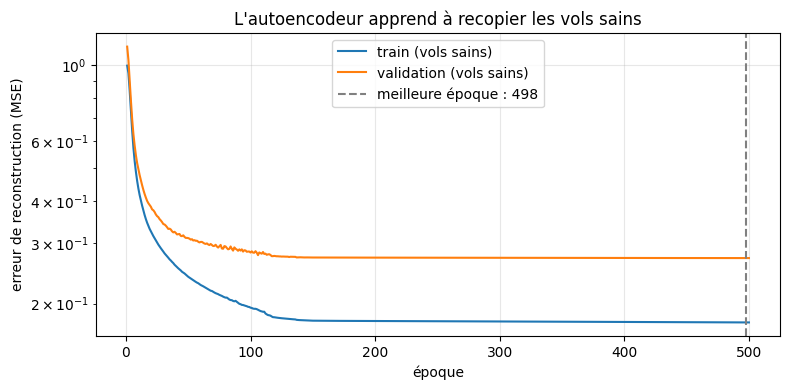

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(courbes.index, courbes["loss"], label="train (vols sains)")
plt.plot(courbes.index, courbes["val_loss"], label="validation (vols sains)")
plt.axvline(meilleure_epoque, color="gray", linestyle="--", label=f"meilleure époque : {meilleure_epoque}")
plt.yscale("log")
plt.xlabel("époque")
plt.ylabel("erreur de reconstruction (MSE)")
plt.title("L'autoencodeur apprend à recopier les vols sains")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/51_courbes_autoencodeur.png", dpi=150)
plt.show()

Un vol usé est reconstruit 6.2 fois moins bien qu'un vol sain (médianes)


,vols,erreur_mediane,erreur_p95
train — sains,1096,0.153,0.396000
validation — sains,244,0.195,0.499000
validation — usés,575,1.203,48.860001


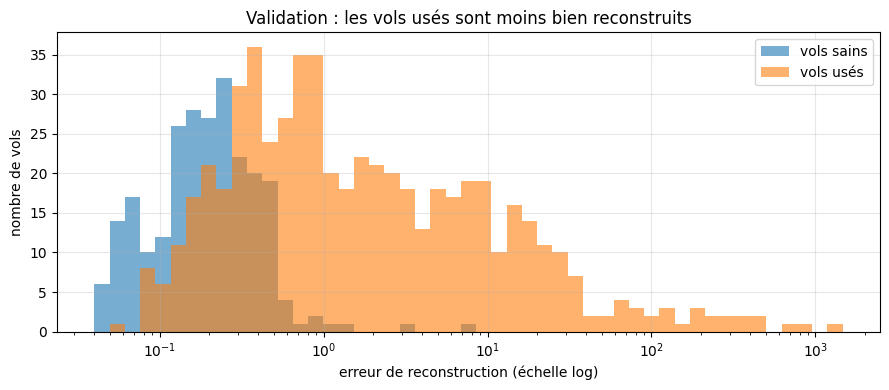

In [7]:
from aeroguard.autoencodeurs import erreur_reconstruction

erreurs_val = erreur_reconstruction(autoencodeur, Xn_val)
erreurs_train_sains = erreur_reconstruction(autoencodeur, X_sains_train)

resume = pd.DataFrame({
    "vols": [len(erreurs_train_sains), sains_val.sum(), (~sains_val).sum()],
    "erreur_mediane": [np.median(erreurs_train_sains), np.median(erreurs_val[sains_val]),
                       np.median(erreurs_val[~sains_val])],
    "erreur_p95": [np.percentile(erreurs_train_sains, 95), np.percentile(erreurs_val[sains_val], 95),
                   np.percentile(erreurs_val[~sains_val], 95)],
}, index=["train — sains", "validation — sains", "validation — usés"])
ratio_medianes = resume.loc["validation — usés", "erreur_mediane"] / resume.loc["validation — sains", "erreur_mediane"]
print(f"Un vol usé est reconstruit {ratio_medianes:.1f} fois moins bien qu'un vol sain (médianes)")
display(resume.round(3))

bornes = np.logspace(np.log10(erreurs_val.min()), np.log10(erreurs_val.max()), 50)
plt.figure(figsize=(9, 4))
plt.hist(erreurs_val[sains_val], bins=bornes, alpha=0.6, label="vols sains")
plt.hist(erreurs_val[~sains_val], bins=bornes, alpha=0.6, label="vols usés")
plt.xscale("log")
plt.xlabel("erreur de reconstruction (échelle log)")
plt.ylabel("nombre de vols")
plt.title("Validation : les vols usés sont moins bien reconstruits")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/51_erreur_sains_uses.png", dpi=150)
plt.show()

In [8]:
from sklearn.metrics import average_precision_score, roc_auc_score

pr_auc_ae = average_precision_score(y_val, erreurs_val)
roc_auc_ae = roc_auc_score(y_val, erreurs_val)

comparaison = pd.DataFrame({
    "type": ["non supervisé", "non supervisé", "supervisé"],
    "a_vu_des_vols_uses": ["non", "non", "oui"],
    "pr_auc_validation": [pr_auc_ae, 0.915, 0.987],
}, index=["autoencodeur dense (5.1)", "Isolation Forest (module 2)", "logistique (module 2)"])
print(f"ROC-AUC de l'autoencodeur : {roc_auc_ae:.3f}")
comparaison.round(3)

ROC-AUC de l'autoencodeur : 0.886


,type,a_vu_des_vols_uses,pr_auc_validation
autoencodeur dense (5.1),non supervisé,non,0.953
Isolation Forest (module 2),non supervisé,non,0.915
logistique (module 2),supervisé,oui,0.987


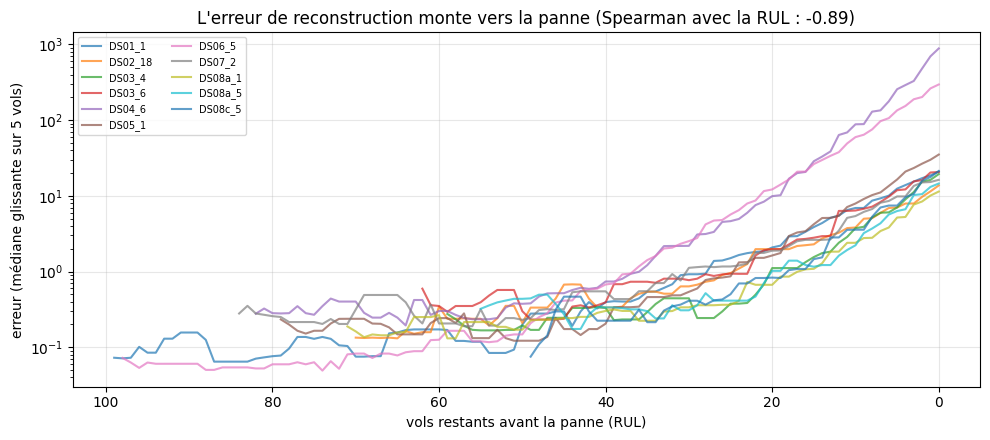

In [9]:
from scipy.stats import spearmanr

suivi = infos_val.assign(erreur=erreurs_val)
correlation_rul, _ = spearmanr(suivi["RUL"], suivi["erreur"])

plt.figure(figsize=(10, 4.5))
for moteur, groupe in suivi.groupby("moteur"):
    groupe = groupe.sort_values("RUL", ascending=False)
    plt.plot(groupe["RUL"], groupe["erreur"].rolling(5, min_periods=1).median(), alpha=0.7, label=moteur)
plt.gca().invert_xaxis()
plt.yscale("log")
plt.xlabel("vols restants avant la panne (RUL)")
plt.ylabel("erreur (médiane glissante sur 5 vols)")
plt.title(f"L'erreur de reconstruction monte vers la panne (Spearman avec la RUL : {correlation_rul:.2f})")
plt.legend(fontsize=7, ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/51_erreur_vs_rul.png", dpi=150)
plt.show()

In [13]:
erreurs_par_feature = erreur_reconstruction(autoencodeur, Xn_val, par_feature=True)
surprise = pd.Series(
    erreurs_par_feature[~sains_val].mean(axis=0) / erreurs_par_feature[sains_val].mean(axis=0),
    index=X_train.columns,
).sort_values(ascending=False)
print("Combien de fois l'erreur est plus grande sur les vols usés que sur les sains :")
surprise.head(10).round(1)

Combien de fois l'erreur est plus grande sur les vols usés que sur les sains :


,0
P21_mean_montee,797.299988
P15_mean_montee,724.299988
P24_mean_montee,581.900024
T30_mean_montee,364.100006
T48_mean_croisiere,340.700012
T50_mean_croisiere,319.899994
P21_mean_descente,300.399994
P15_mean_descente,286.200012
T50_mean_montee,281.700012
T48_mean_montee,248.699997


In [11]:
CHEMIN_MODELE = f"{DOSSIER}/models/autoencodeur_dense_v5.keras"
CHEMIN_STATS = f"{DOSSIER}/models/autoencodeur_dense_v5_stats.npz"
autoencodeur.save(CHEMIN_MODELE)
np.savez(CHEMIN_STATS, moyennes=moyennes, ecarts=ecarts,
         medianes_imputation=imputeur.statistics_, colonnes=np.array(X_train.columns))

mlflow.set_experiment("aeroguard-anomalies")
with mlflow.start_run(run_name="autoencodeur_dense") as run:
    mlflow.log_params({
        "modele": "autoencodeur_dense", "architecture": "126-64-16-8-16-64-126",
        "taille_goulot": 8, "entrainement": "vols sains du train uniquement",
        "vols_entrainement": int(sains_train.sum()), "normalisation": "stats des vols sains du train",
        "parametres_entrainables": nombre_parametres_entrainables(autoencodeur),
    })
    mlflow.log_metrics({
        "perte_val_min": float(courbes["val_loss"].min()), "meilleure_epoque": meilleure_epoque,
        "duree_entrainement_s": duree_entrainement, "pr_auc_val": pr_auc_ae, "roc_auc_val": roc_auc_ae,
        "ratio_erreur_mediane": ratio_medianes, "spearman_rul": correlation_rul,
    })
    for figure in ["51_courbes_autoencodeur", "51_erreur_sains_uses", "51_erreur_vs_rul"]:
        mlflow.log_artifact(f"{DOSSIER}/results/figures/{figure}.png")
    mlflow.log_artifact(CHEMIN_MODELE)
    mlflow.log_artifact(CHEMIN_STATS)
    mlflow.set_tags({"lecon": "5.1", "tache": "anomalie", "jeu": "validation"})
print("✅ Modèle et run enregistrés :", run.info.run_id[:8])

2026/10/09 08:18:08 INFO mlflow.tracking.fluent: Experiment with name 'aeroguard-anomalies' does not exist. Creating a new experiment.


✅ Modèle et run enregistrés : 9d1829f5


In [12]:
dossiers_artifacts = set()
for experience in mlflow.search_experiments():
    emplacement = experience.artifact_location.replace("file://", "")
    if emplacement.startswith("/content") and not emplacement.startswith("/content/drive"):
        dossiers_artifacts.add(os.path.dirname(emplacement))

shutil.copytree(DOSSIER_MLFLOW_LOCAL, DOSSIER_MLFLOW_DRIVE, dirs_exist_ok=True)
for dossier in dossiers_artifacts:
    if os.path.exists(dossier):
        shutil.copytree(dossier, f"{DOSSIER}/{os.path.basename(dossier)}", dirs_exist_ok=True)
print("✅ MLflow sauvegardé sur Drive")

✅ MLflow sauvegardé sur Drive
